# 🧠 Human Fatigue Prediction
## Analisis & Machine Learning Pipeline
**Dataset:** Human Fatigue CSV  
**Model:** Random Forest Classifier  
**Author:** (nama Anda)  
**Date:** 2025  

---
### 📋 Daftar Isi
1. Import Library
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Preprocessing
7. Model Training & Evaluation
8. Save Model

In [54]:
# ================================================
# CELL 1 — IMPORT LIBRARY
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [55]:
# ================================================
# CELL 2 — LOAD DATASET
# ================================================

df = pd.read_csv('../data/human_fatigue.csv')

print(f"✅ Dataset berhasil diload!")
print(f"📊 Jumlah baris  : {df.shape[0]}")
print(f"📊 Jumlah kolom  : {df.shape[1]}")
print(f"📊 Kolom         : {list(df.columns)}")

✅ Dataset berhasil diload!
📊 Jumlah baris  : 25000
📊 Jumlah kolom  : 13
📊 Kolom         : ['Hours_Awake', 'Decisions_Made', 'Task_Switches', 'Avg_Decision_Time_sec', 'Sleep_Hours_Last_Night', 'Time_of_Day', 'Caffeine_Intake_Cups', 'Stress_Level_1_10', 'Error_Rate', 'Cognitive_Load_Score', 'Decision_Fatigue_Score', 'Fatigue_Level', 'System_Recommendation']


In [56]:
# =========================
# 1. LIHAT DATA AWAL
# =========================
print("=== HEAD ===")
display(df.head(2))

# =========================
# 2. INFO DATA
# =========================
print("=== INFO ===")
df.info()

# =========================
# 3. CEK MISSING VALUE
# =========================
print("=== MISSING VALUES ===")
print(df.isnull().sum())

# =========================
# 4. STATISTIK DATA
# =========================
print("=== DESCRIBE ===")
display(df.describe())

# =========================
# 5. CEK DATA DUPLIKAT
# =========================
print("=== DUPLICATE ===")
print(df.duplicated().sum())

=== HEAD ===


,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Time_of_Day,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score,Fatigue_Level,System_Recommendation
0,7,28,7,2.30,5.8,Evening,0,2.4,0.000,2.6,15.6,Low,Continue
1,15,77,22,3.65,4.5,Afternoon,3,1.9,0.143,4.5,97.3,High,Take Break


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Hours_Awake             25000 non-null  int64  
 1   Decisions_Made          25000 non-null  int64  
 2   Task_Switches           25000 non-null  int64  
 3   Avg_Decision_Time_sec   25000 non-null  float64
 4   Sleep_Hours_Last_Night  25000 non-null  float64
 5   Time_of_Day             25000 non-null  str    
 6   Caffeine_Intake_Cups    25000 non-null  int64  
 7   Stress_Level_1_10       25000 non-null  float64
 8   Error_Rate              25000 non-null  float64
 9   Cognitive_Load_Score    25000 non-null  float64
 10  Decision_Fatigue_Score  25000 non-null  float64
 11  Fatigue_Level           25000 non-null  str    
 12  System_Recommendation   25000 non-null  str    
dtypes: float64(6), int64(4), str(3)
memory usage: 3.0 MB
=== MISSING VALUES ===
Hours_Awake  

,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,9.088280,45.433080,13.623480,2.918346,6.085956,1.897240,2.202736,0.031877,3.365784,40.579280
std,4.928093,25.611583,8.521595,0.942644,1.114586,1.430483,1.329868,0.057457,1.729092,36.704221
min,1.000000,0.000000,0.000000,0.500000,2.000000,0.000000,1.000000,0.000000,0.600000,0.000000
25%,5.000000,23.000000,7.000000,2.270000,5.300000,1.000000,1.000000,0.000000,1.900000,0.000000
50%,9.000000,45.000000,13.000000,2.910000,6.100000,2.000000,1.800000,0.000000,3.200000,34.650000
75%,13.000000,67.000000,20.000000,3.550000,6.900000,3.000000,3.100000,0.045000,4.600000,74.200000
max,17.000000,117.000000,48.000000,6.800000,9.000000,6.000000,8.700000,0.359000,9.700000,100.000000


=== DUPLICATE ===
1


In [57]:
# ================================================
# CELL 3 — DATA UNDERSTANDING
# ================================================

print("=" * 50)
print("HEAD — 5 Data Pertama")
print("=" * 50)
display(df.head())

print("\n" + "=" * 50)
print("INFO — Tipe Data & Non-Null Count")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
display(df.describe())

print("\n" + "=" * 50)
print("MISSING VALUES per Kolom")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("DISTRIBUSI TARGET — Fatigue_Level")
print("=" * 50)
print(df['Fatigue_Level'].value_counts())

HEAD — 5 Data Pertama


,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Time_of_Day,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score,Fatigue_Level,System_Recommendation
0,7,28,7,2.30,5.8,Evening,0,2.4,0.000,2.6,15.6,Low,Continue
1,15,77,22,3.65,4.5,Afternoon,3,1.9,0.143,4.5,97.3,High,Take Break
2,11,57,23,3.67,6.8,Night,2,2.1,0.000,4.1,55.4,Moderate,Slow Down
3,8,39,10,2.39,5.3,Afternoon,1,1.0,0.000,2.3,29.7,Low,Continue
4,7,46,16,3.05,8.2,Night,1,2.8,0.000,3.9,19.1,Low,Continue



INFO — Tipe Data & Non-Null Count
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Hours_Awake             25000 non-null  int64  
 1   Decisions_Made          25000 non-null  int64  
 2   Task_Switches           25000 non-null  int64  
 3   Avg_Decision_Time_sec   25000 non-null  float64
 4   Sleep_Hours_Last_Night  25000 non-null  float64
 5   Time_of_Day             25000 non-null  str    
 6   Caffeine_Intake_Cups    25000 non-null  int64  
 7   Stress_Level_1_10       25000 non-null  float64
 8   Error_Rate              25000 non-null  float64
 9   Cognitive_Load_Score    25000 non-null  float64
 10  Decision_Fatigue_Score  25000 non-null  float64
 11  Fatigue_Level           25000 non-null  str    
 12  System_Recommendation   25000 non-null  str    
dtypes: float64(6), int64(4), str(3)
memory usage: 3.0 MB

STATISTIK DES

,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,9.088280,45.433080,13.623480,2.918346,6.085956,1.897240,2.202736,0.031877,3.365784,40.579280
std,4.928093,25.611583,8.521595,0.942644,1.114586,1.430483,1.329868,0.057457,1.729092,36.704221
min,1.000000,0.000000,0.000000,0.500000,2.000000,0.000000,1.000000,0.000000,0.600000,0.000000
25%,5.000000,23.000000,7.000000,2.270000,5.300000,1.000000,1.000000,0.000000,1.900000,0.000000
50%,9.000000,45.000000,13.000000,2.910000,6.100000,2.000000,1.800000,0.000000,3.200000,34.650000
75%,13.000000,67.000000,20.000000,3.550000,6.900000,3.000000,3.100000,0.045000,4.600000,74.200000
max,17.000000,117.000000,48.000000,6.800000,9.000000,6.000000,8.700000,0.359000,9.700000,100.000000



MISSING VALUES per Kolom
Hours_Awake               0
Decisions_Made            0
Task_Switches             0
Avg_Decision_Time_sec     0
Sleep_Hours_Last_Night    0
Time_of_Day               0
Caffeine_Intake_Cups      0
Stress_Level_1_10         0
Error_Rate                0
Cognitive_Load_Score      0
Decision_Fatigue_Score    0
Fatigue_Level             0
System_Recommendation     0
dtype: int64

DISTRIBUSI TARGET — Fatigue_Level
Fatigue_Level
Low         11729
High         8404
Moderate     4867
Name: count, dtype: int64


In [58]:
# ================================================
# CELL 4 — DATA CLEANING
# ================================================

print(f"Shape sebelum cleaning : {df.shape}")

# --------------------------
# 1. Hapus Duplikat
# --------------------------
df = df.drop_duplicates()
print(f"Shape setelah drop duplikat : {df.shape}")

# --------------------------
# 2. Drop Kolom Tidak Relevan
# --------------------------

# System_Recommendation → data leakage (label turunan dari target)
# Decision_Fatigue_Score → data leakage (korelasi terlalu tinggi dengan target)

cols_to_drop = ['System_Recommendation', 'Decision_Fatigue_Score']
df = df.drop(columns=cols_to_drop)

print(f"Shape setelah drop kolom leakage : {df.shape}")
print(f"\n✅ Kolom yang tersisa:")
print(list(df.columns))

Shape sebelum cleaning : (25000, 13)
Shape setelah drop duplikat : (24999, 13)
Shape setelah drop kolom leakage : (24999, 11)

✅ Kolom yang tersisa:
['Hours_Awake', 'Decisions_Made', 'Task_Switches', 'Avg_Decision_Time_sec', 'Sleep_Hours_Last_Night', 'Time_of_Day', 'Caffeine_Intake_Cups', 'Stress_Level_1_10', 'Error_Rate', 'Cognitive_Load_Score', 'Fatigue_Level']


In [59]:
print("=== df shape ===")
df.shape

=== df shape ===


(24999, 11)

In [60]:
print("=== df columns ===")
df.columns

=== df columns ===


Index(['Hours_Awake', 'Decisions_Made', 'Task_Switches',
       'Avg_Decision_Time_sec', 'Sleep_Hours_Last_Night', 'Time_of_Day',
       'Caffeine_Intake_Cups', 'Stress_Level_1_10', 'Error_Rate',
       'Cognitive_Load_Score', 'Fatigue_Level'],
      dtype='str')

In [61]:
# setting visual
sns.set(style="whitegrid")

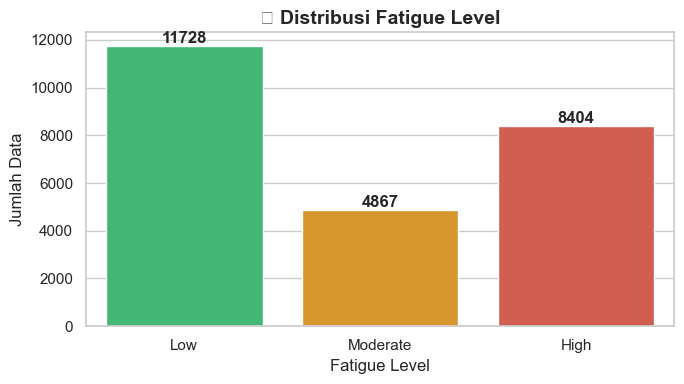


📊 Proporsi:
Fatigue_Level
Low         46.9
High        33.6
Moderate    19.5
Name: proportion, dtype: float64


In [62]:
# ================================================
# CELL 5 — EDA: DISTRIBUSI TARGET
# ================================================

plt.figure(figsize=(7, 4))
order = ['Low', 'Moderate', 'High']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

ax = sns.countplot(
    x='Fatigue_Level',
    data=df,
    order=order,
    palette=colors
)

# Tambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.title('📊 Distribusi Fatigue Level', fontsize=14, fontweight='bold')
plt.xlabel('Fatigue Level')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.savefig('../output/fatigue_distribution.png', dpi=150)
plt.show()

print("\n📊 Proporsi:")
print(df['Fatigue_Level'].value_counts(normalize=True).round(3) * 100)

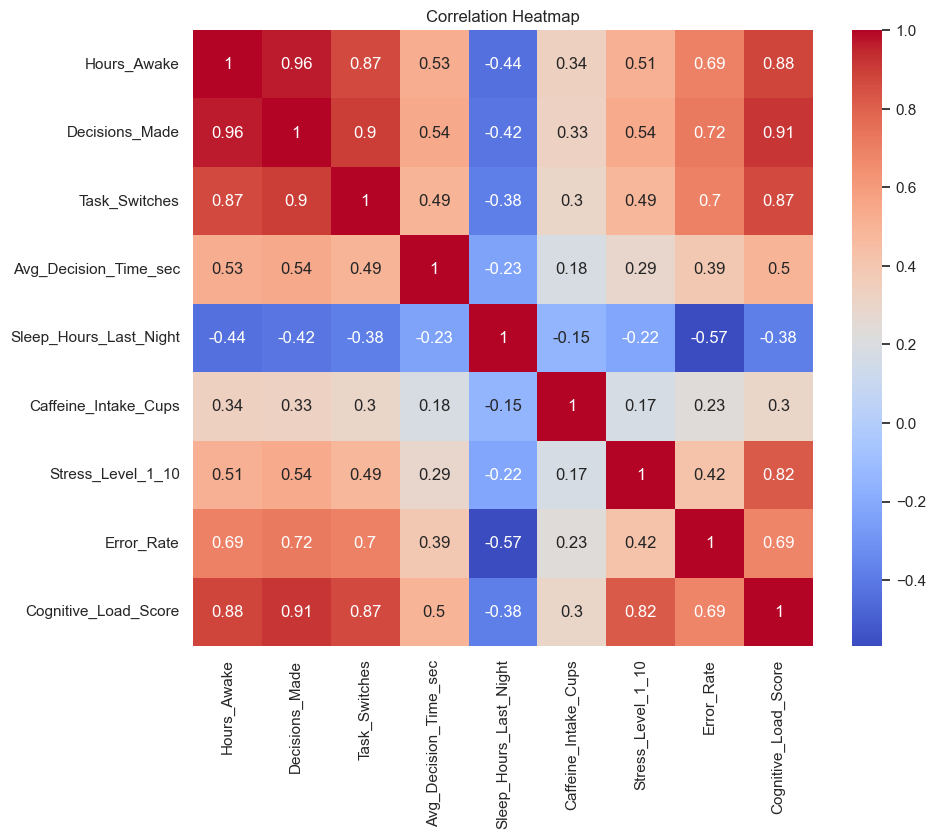

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

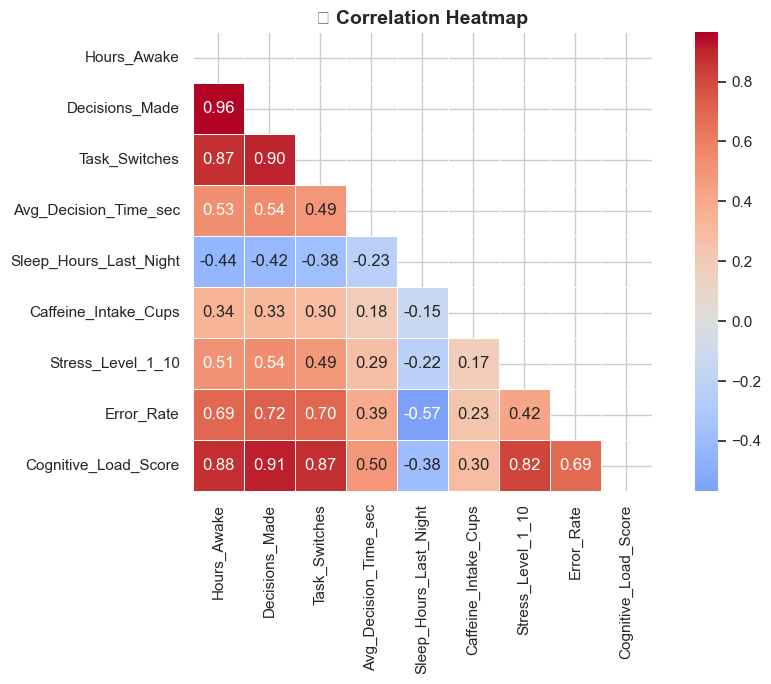

In [64]:
# ================================================
# CELL 6 — EDA: CORRELATION HEATMAP
# ================================================

plt.figure(figsize=(10, 7))
corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('🔥 Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/correlation_heatmap.png', dpi=150)
plt.show()

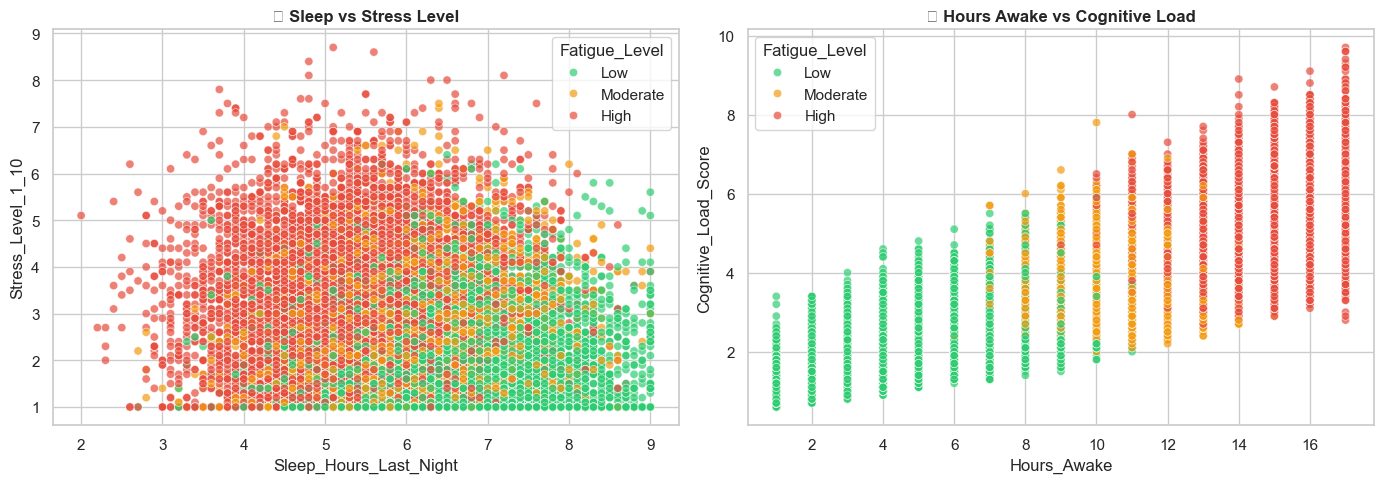

In [65]:
# ================================================
# CELL 8 — EDA: SCATTER PLOT
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'Low': '#2ecc71', 'Moderate': '#f39c12', 'High': '#e74c3c'}

# Plot 1: Sleep vs Stress
sns.scatterplot(
    x='Sleep_Hours_Last_Night',
    y='Stress_Level_1_10',
    hue='Fatigue_Level',
    hue_order=['Low', 'Moderate', 'High'],
    palette=palette,
    data=df,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('😴 Sleep vs Stress Level', fontweight='bold')

# Plot 2: Hours Awake vs Cognitive Load
sns.scatterplot(
    x='Hours_Awake',
    y='Cognitive_Load_Score',
    hue='Fatigue_Level',
    hue_order=['Low', 'Moderate', 'High'],
    palette=palette,
    data=df,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('⏰ Hours Awake vs Cognitive Load', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/scatter_plots.png', dpi=150)
plt.show()

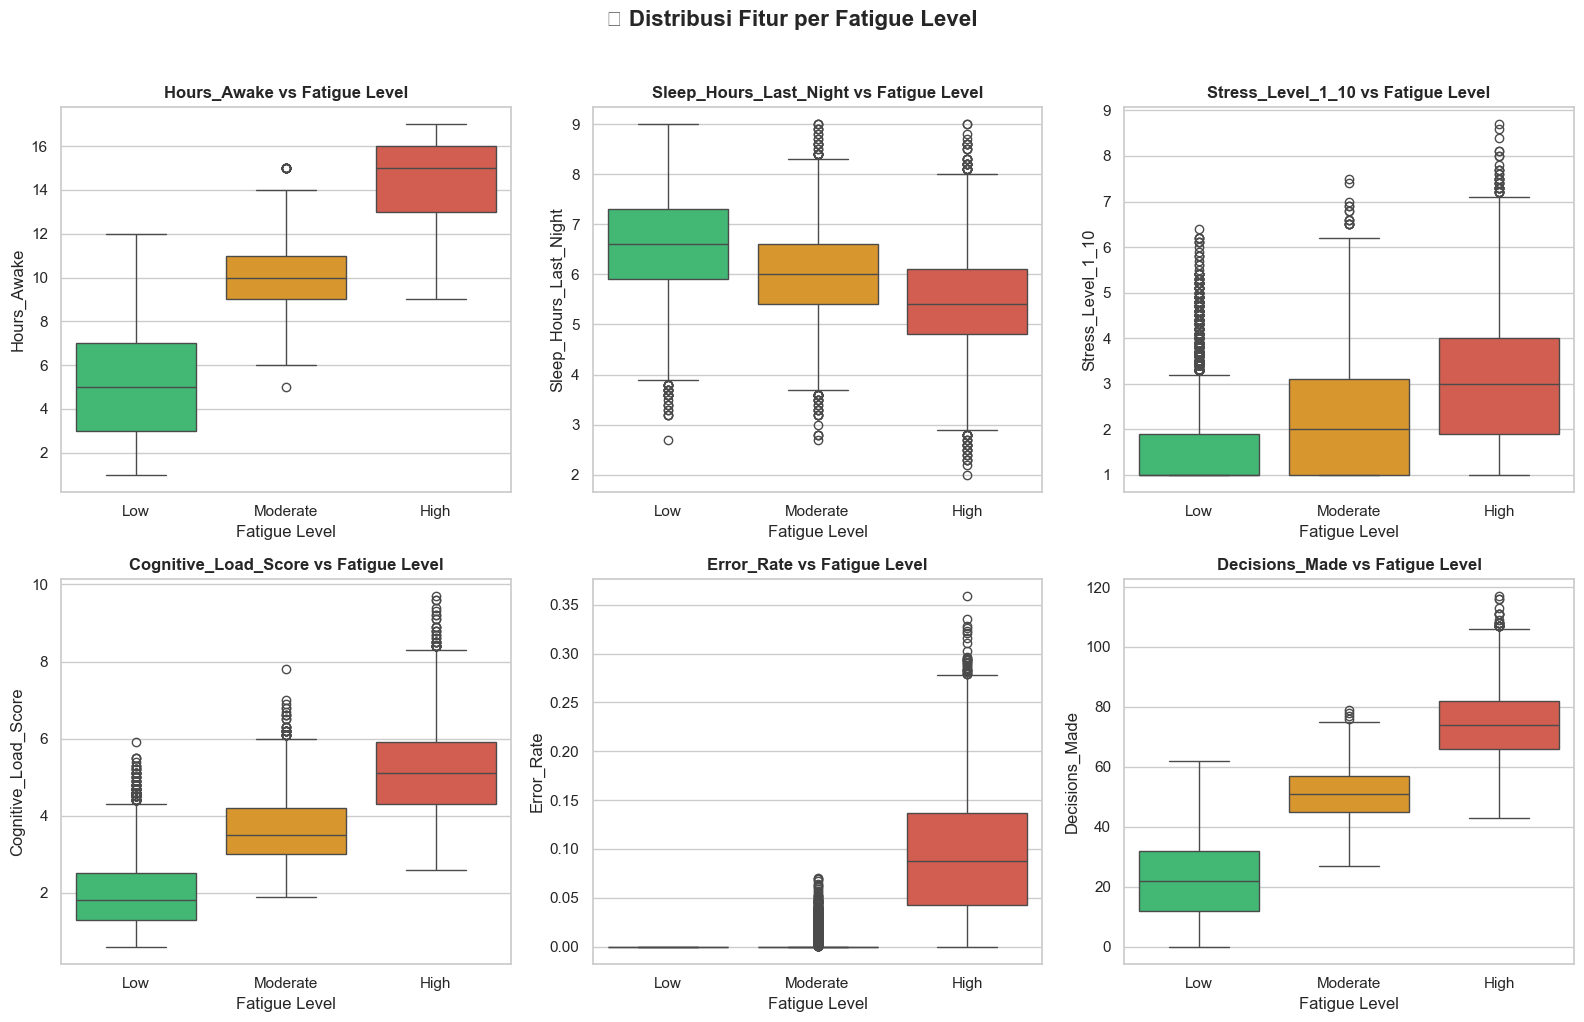

In [66]:
# ================================================
# CELL 7 — EDA: BOXPLOT FITUR vs FATIGUE LEVEL
# ================================================

numeric_cols = [
    'Hours_Awake', 'Sleep_Hours_Last_Night',
    'Stress_Level_1_10', 'Cognitive_Load_Score',
    'Error_Rate', 'Decisions_Made'
]

order = ['Low', 'Moderate', 'High']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x='Fatigue_Level',
        y=col,
        data=df,
        order=order,
        palette=colors,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Fatigue Level', fontweight='bold')
    axes[i].set_xlabel('Fatigue Level')
    axes[i].set_ylabel(col)

plt.suptitle('📦 Distribusi Fitur per Fatigue Level', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/boxplot_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
print("=== Debug ===")

=== Debug ===


In [68]:
df.corr(numeric_only=True)

,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score
Hours_Awake,1.000000,0.964409,0.869039,0.528513,-0.437112,0.338442,0.512668,0.694236,0.879355
Decisions_Made,0.964409,1.000000,0.901387,0.544786,-0.419827,0.327993,0.538229,0.718634,0.914953
Task_Switches,0.869039,0.901387,1.000000,0.493227,-0.378195,0.296553,0.485226,0.696476,0.870986
Avg_Decision_Time_sec,0.528513,0.544786,0.493227,1.000000,-0.232316,0.181156,0.286511,0.392622,0.495779
Sleep_Hours_Last_Night,-0.437112,-0.419827,-0.378195,-0.232316,1.000000,-0.147453,-0.221974,-0.567523,-0.382376
Caffeine_Intake_Cups,0.338442,0.327993,0.296553,0.181156,-0.147453,1.000000,0.174928,0.234561,0.299596
Stress_Level_1_10,0.512668,0.538229,0.485226,0.286511,-0.221974,0.174928,1.000000,0.421063,0.820086
Error_Rate,0.694236,0.718634,0.696476,0.392622,-0.567523,0.234561,0.421063,1.000000,0.685356
Cognitive_Load_Score,0.879355,0.914953,0.870986,0.495779,-0.382376,0.299596,0.820086,0.685356,1.000000


Training Model (Perbandingan ML)

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [71]:
# ================================================
# CELL 9+10 — PREPROCESSING + TRAIN 3 MODELS
# (DIGABUNG AGAR TIDAK ADA MASALAH URUTAN)
# ================================================

# --------------------------
# 1. Pisahkan Fitur & Target
# --------------------------
X = df.drop(columns=['Fatigue_Level'])
y = df['Fatigue_Level']

# --------------------------
# 2. Label Encode Target
# --------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("✅ Mapping Label:")
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))
print(mapping)

# --------------------------
# 3. Definisi Fitur
# --------------------------
numeric_features = [
    'Hours_Awake',
    'Decisions_Made',
    'Task_Switches',
    'Avg_Decision_Time_sec',
    'Sleep_Hours_Last_Night',
    'Caffeine_Intake_Cups',
    'Stress_Level_1_10',
    'Error_Rate',
    'Cognitive_Load_Score'
]

categorical_features = ['Time_of_Day']

# --------------------------
# 4. Preprocessing Pipeline
# --------------------------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# --------------------------
# 5. Train Test Split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\n✅ Train size : {X_train.shape}")
print(f"✅ Test size  : {X_test.shape}")

# --------------------------
# 6. Definisi 3 Model
# --------------------------
models = {
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=8,
            min_samples_split=5,
            random_state=42
        ))
    ]),
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])
}

# --------------------------
# 7. Training & Evaluasi
# --------------------------
results = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'pipeline': pipeline,
        'accuracy': acc,
        'y_pred': y_pred
    }
    print(f"\n{'='*40}")
    print(f"📊 {name}")
    print(f"{'='*40}")
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_
    ))

✅ Mapping Label:
{'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}

✅ Train size : (19999, 10)
✅ Test size  : (5000, 10)

📊 Random Forest
Accuracy : 0.9688 (96.88%)
              precision    recall  f1-score   support

        High       0.98      0.98      0.98      1681
         Low       0.99      0.98      0.98      2346
    Moderate       0.91      0.93      0.92       973

    accuracy                           0.97      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.97      0.97      0.97      5000


📊 Decision Tree
Accuracy : 0.9576 (95.76%)
              precision    recall  f1-score   support

        High       0.97      0.98      0.98      1681
         Low       0.97      0.97      0.97      2346
    Moderate       0.89      0.89      0.89       973

    accuracy                           0.96      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.96      0.96      0.96      5000


📊 Logistic 

Confusion Matrix

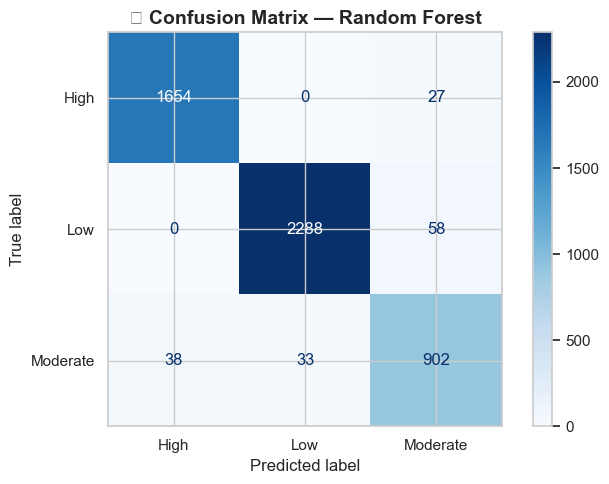

In [72]:
# ================================================
# CELL 11 — CONFUSION MATRIX (RANDOM FOREST)
# ================================================

best_model = results['Random Forest']['pipeline']
y_pred_rf  = results['Random Forest']['y_pred']

cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(cmap='Blues', ax=ax)
ax.set_title('🎯 Confusion Matrix — Random Forest', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/confusion_matrix.png', dpi=150)
plt.show()

Feature Importance (Random Forest)

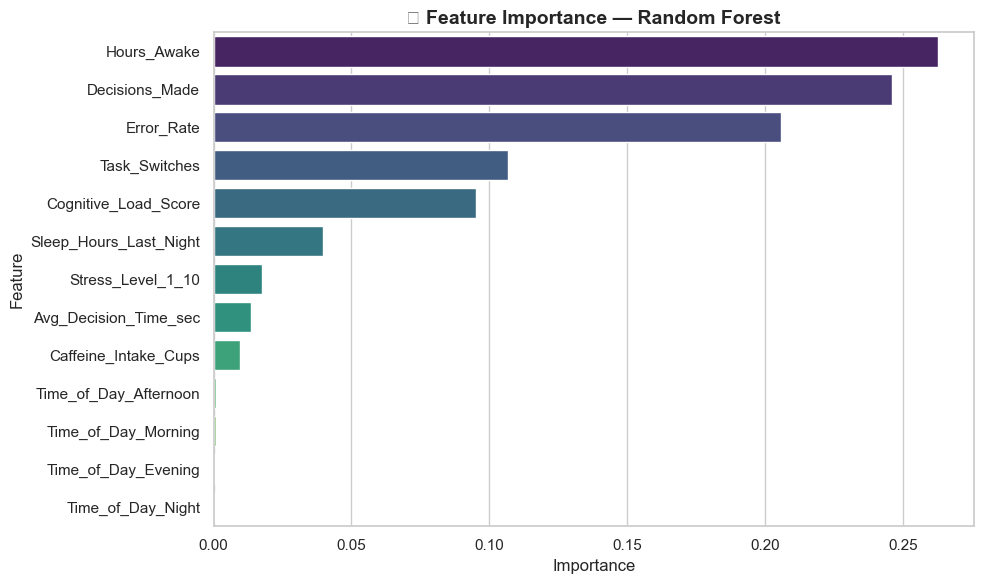


Top 5 Fitur Terpenting:
             Feature  Importance
         Hours_Awake    0.262702
      Decisions_Made    0.245918
          Error_Rate    0.205891
       Task_Switches    0.106793
Cognitive_Load_Score    0.095157


In [73]:
# ================================================
# CELL 12 — FEATURE IMPORTANCE
# ================================================

rf_classifier = best_model.named_steps['classifier']
preprocessor_fitted = best_model.named_steps['preprocessor']

# Ambil nama kolom setelah preprocessing
ohe_cols = (preprocessor_fitted
            .named_transformers_['cat']
            .named_steps['onehot']
            .get_feature_names_out(['Time_of_Day']))

feature_names = numeric_features + list(ohe_cols)
importances   = rf_classifier.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_df,
    palette='viridis'
)
plt.title('🌟 Feature Importance — Random Forest', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 Fitur Terpenting:")
print(feat_df.head(5).to_string(index=False))

## Modify Notebook

In [74]:
# ================================================
# CELL 13 — SAVE MODEL
# ================================================
import joblib
import os
os.makedirs('../model', exist_ok=True)

# Save model pipeline
joblib.dump(best_model, '../model/fatigue_model.pkl')

# Save label encoder
joblib.dump(label_encoder, '../model/label_encoder.pkl')

# Save nama kolom (PENTING untuk Streamlit)
joblib.dump(list(X.columns), '../model/columns.pkl')

print("✅ Model saved      : model/fatigue_model.pkl")
print("✅ Encoder saved    : model/label_encoder.pkl")
print("✅ Columns saved    : model/columns.pkl")
print(f"\n📋 Kolom yang disimpan:")
print(list(X.columns))

✅ Model saved      : model/fatigue_model.pkl
✅ Encoder saved    : model/label_encoder.pkl
✅ Columns saved    : model/columns.pkl

📋 Kolom yang disimpan:
['Hours_Awake', 'Decisions_Made', 'Task_Switches', 'Avg_Decision_Time_sec', 'Sleep_Hours_Last_Night', 'Time_of_Day', 'Caffeine_Intake_Cups', 'Stress_Level_1_10', 'Error_Rate', 'Cognitive_Load_Score']


Mapping target:
{'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}